# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

      Dataset ini diambil dari Kaggle https://www.kaggle.com/datasets/sonialikhan/heart-attack-analysis-and-prediction-dataset Dataset Analisis & Prediksi Serangan Jantung adalah dataset yang digunakan untuk penelitian dan analisis di bidang kesehatan kardiovaskular. Dataset ini biasanya berisi berbagai atribut yang berkaitan dengan kesehatan dan gaya hidup individu, beserta indikator apakah individu tersebut pernah mengalami serangan jantung atau tidak.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Memastikan plot muncul di dalam notebook
%matplotlib inline

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
# Membaca dataset
df = pd.read_csv('heart.csv')

# Menampilkan 5 baris pertama untuk memastikan data terbaca
display(df.head())

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Umum Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
--------------------------------------------------
Jumlah Data Kosong (Missing Values):
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh 

/tmp/ipykernel_1219/2853600526.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='output', palette='Set2')


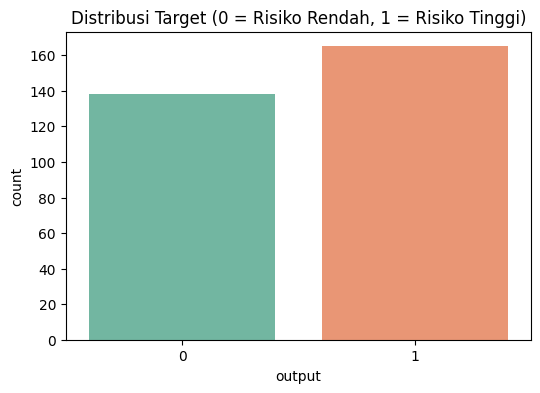

In [4]:
print("Informasi Umum Dataset:")
df.info()
print("-" * 50)

print("Jumlah Data Kosong (Missing Values):")
print(df.isnull().sum())
print("-" * 50)

print(f"Jumlah Data Duplikat: {df.duplicated().sum()}")
print("-" * 50)

# Visualisasi distribusi target (kolom 'output')
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='output', palette='Set2')
plt.title('Distribusi Target (0 = Risiko Rendah, 1 = Risiko Tinggi)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
# 1. Menghapus data duplikat
df_clean = df.drop_duplicates()
print(f"Jumlah baris setelah duplikat dihapus: {df_clean.shape[0]}\n")

# 2. Memisahkan Fitur (X) dan Target (y)
# Gunakan 'output' sebagai target
X = df_clean.drop('output', axis=1)
y = df_clean['output']

# 3. Membagi data menjadi Data Latih (Train) dan Data Uji (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Melakukan Standarisasi (Scaling) pada fitur numerik
# Menggunakan 'thalachh' sesuai nama di dataset
numerical_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Data berhasil diproses dan siap dilatih!")
display(X_train.head())

Jumlah baris setelah duplikat dihapus: 302

Data berhasil diproses dan siap dilatih!


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall
59,0.289062,0,0,-0.192086,1.222784,0,0,0.405122,0,-0.889676,2,1,2
247,1.267182,1,1,1.590543,0.035438,0,1,-1.364273,1,-0.889676,1,3,1
289,0.071702,0,0,-0.192086,-0.818618,0,2,-0.910582,1,0.771788,1,1,3
288,0.289062,1,0,-1.194814,1.889363,0,1,-0.320784,1,1.602520,1,1,3
64,0.397742,1,2,0.476400,-0.693634,1,0,0.677336,0,-0.889676,2,0,2


In [6]:
# 5. Menyimpan hasil preprocessing ke dalam file CSV (Syarat Dicoding)
df_clean.to_csv('dataset_preprocessed.csv', index=False)
print("Data bersih berhasil disimpan ke dalam file 'dataset_preprocessed.csv'")

Data bersih berhasil disimpan ke dalam file 'dataset_preprocessed.csv'
